### Age Detection of Indian Actors

In [1]:
# Importing necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from tensorflow.python.keras import utils
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer
import keras
import imageio # To read images
from PIL import Image # For image resizing 

In [6]:
# Reading the data
train = pd.read_csv('D:\\AI\\Python\\new_batch\\agedetectiontrain\\train.csv')
test = pd.read_csv('D:\\AI\\Python\\new_batch\\agedetectiontest\\test.csv')

17673
Age group: MIDDLE


C:\Users\Dhrumil Prajapati\AppData\Local\Temp\ipykernel_21804\2231640876.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join('D:\\AI\\Python\\new_batch\\agedetectiontrain\\Train', img_name))


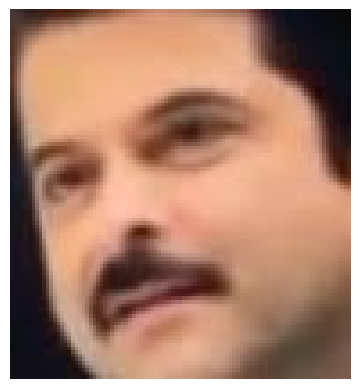

In [8]:
# Displaying any random movie character along with age group
np.random.seed(10)
idx = np.random.choice(train.index)
print(idx)
img_name = train.ID[idx]
img = imageio.imread(os.path.join('D:\\AI\\Python\\new_batch\\agedetectiontrain\\Train', img_name))

print('Age group:', train.Class[idx])
plt.imshow(img)
plt.axis('off')
plt.show()

### Few problems with the images:
- Variations in shape: One image has a shape of (66, 46) whereas another has (102, 87).
- Multiple viewpoints: Faces with different view possible!
- Discrepancy in brightness and contrast.
- Quality of images: Some images were found to be too pixelated.

In [10]:
temp = []
for img_name in train.ID:
    img_path = os.path.join('D:\\AI\\Python\\new_batch\\agedetectiontrain\\Train', img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')    
    temp.append(img)

train_x = np.stack(temp)

C:\Users\Dhrumil Prajapati\AppData\Local\Temp\ipykernel_21804\1675333296.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [13]:
# Image resizing of test data into single numpy array
temp = []
for img_name in test.ID:
    img_path = os.path.join('D:\\AI\\Python\\new_batch\\agedetectiontest\\Test', img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')    
    temp.append(img)

test_x = np.stack(temp)

C:\Users\Dhrumil Prajapati\AppData\Local\Temp\ipykernel_21804\1990967121.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [14]:
# Normalizing the images
train_x = train_x / 255.
test_x = test_x / 255.

In [15]:
# Knowing the distribution of classes in data
train.Class.value_counts(normalize=True)

Class
MIDDLE    0.542751
YOUNG     0.336883
OLD       0.120366
Name: proportion, dtype: float64

In [18]:
# Encoding the categorical variable to numeric
lb = LabelEncoder()
train_y = lb.fit_transform(train.Class)
train_y = keras.utils.to_categorical(
    train_y,
    num_classes=len(lb.classes_)
)

### Building a Deep Neural Network for Age Group Detection

In [20]:
# Specifying all the parameters we will be using in our network
input_num_units = (32, 32, 3)
hidden_num_units = 500
output_num_units = 3

epochs = 5
batch_size = 128

In [21]:
# Defining the network
input_num_units = (32, 32, 3)
hidden_num_units = 500
output_num_units = 3

model = Sequential([
  InputLayer(input_shape=input_num_units),
  Flatten(),
  Dense(units=hidden_num_units, activation='relu'),
  Dense(units=output_num_units, activation='softmax'),
])

d:\AI\Python\new_batch\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [22]:
# Printing model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     1,536,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,538,003 (5.87 MB)

 Trainable params: 1,538,003 (5.87 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compiling and Training Network
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_x, train_y, batch_size=batch_size,epochs=epochs,verbose=1)

Epoch 1/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5666 - loss: 0.9004
Epoch 2/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6045 - loss: 0.8438
Epoch 3/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6160 - loss: 0.8239
Epoch 4/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6222 - loss: 0.8153
Epoch 5/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6312 - loss: 0.8044


In [24]:
# Training model along with validation data
model.fit(train_x, train_y, batch_size=batch_size,epochs=epochs,verbose=1, validation_split=0.2)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6318 - loss: 0.7998 - val_accuracy: 0.6339 - val_loss: 0.8042
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6326 - loss: 0.7961 - val_accuracy: 0.6447 - val_loss: 0.7827
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6429 - loss: 0.7874 - val_accuracy: 0.6143 - val_loss: 0.8181
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6408 - loss: 0.7867 - val_accuracy: 0.6537 - val_loss: 0.7756
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6441 - loss: 0.7834 - val_accuracy: 0.6464 - val_loss: 0.7882


In [26]:
# Predicting and importing the result in a csv file
pred_probabilities = model.predict(test_x, verbose=0)
pred = np.argmax(pred_probabilities, axis=1)
pred = lb.inverse_transform(pred)

test['Class'] = pred
test.to_csv('out.csv', index=False)

C:\Users\Dhrumil Prajapati\AppData\Local\Temp\ipykernel_21804\2408968827.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join('D:\\AI\\Python\\new_batch\\agedetectiontest\\Test', img_name))


Original: YOUNG Predicted: YOUNG
Original: YOUNG Predicted: YOUNG


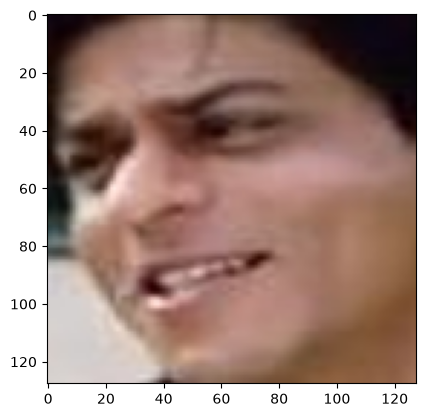

In [40]:
# Visual Inspection of predictions
idx = 5263
img_name = test.ID[idx]

img = imageio.imread(os.path.join('D:\\AI\\Python\\new_batch\\agedetectiontest\\Test', img_name))
plt.imshow(np.array(Image.fromarray(img).resize((128, 128))))
pred_probabilities = model.predict(test_x, verbose=0)
pred_indices = np.argmax(pred_probabilities, axis=1)

print('Original:', test.Class[idx],
    'Predicted:', lb.inverse_transform([pred_indices[idx]])[0])
print('Original:', test.Class.iloc[idx], 'Predicted:', pred[idx])

#### This is the result at current 64.51% training accuracy of the model. 
#### The model can be further improved using hyper-parameter tuning as well as using other image processing techniques.